# Assignment 1
Name: Aoi Ueno  

Problem: For this assignment, we focus on data exploration and feature engineering for the following machine learning problem: 
Given client and campaign information available at the time of contact, predict whether the client subscribes to a term deposit (i.e., a type of short-term investment)

## 1. Identifying the Prediction Target

- Inspect the dataset and identify which column should be treated as the target variable for this assignment.
- Justify why this column represents the appropriate prediction objective in the context of the marketing
campaign.
- Identify at least two other variables that could superficially appear to be valid targets and explain why they
should not be treated as the prediction objective.

- Inspect the dataset and identify which column should be treated as the target variable for this assignment.

ANSWER:

I selected y as the target variable because it directly represents the objective of the marketing campaign. "Does a client subscribes to a term deposit?"

The purpose of the campaign is to predict if a contacted client will subscribe or not. The variable y captures this outcome with two possible values, "yes" or "no".The target variable must reflect the real-world outcome that the organization wants to predict. In this case, y directly represents that outcome.

WHY NOT OTHER COLUMNS?:
1. poutcome : This shows the outcome of a previous marketing campaign. It can influence the current decision a bit, but it is not exactly the result we are trying to predict.

2.campaign: This variable shows how many contacts were made during the campaign. It does not represent the final outcome of the campaign = subscription. It is just a  part of the process, not the result i am looking for.

## 2. data loading and exploration

Before applying any splitting, I first need to explore the dataset.
According to lecture 2, data inspection must be done before modeling. 

Aim to understand:
Data types (numerical vs categorical variables)
The structure of the dataset
Missing values

At this stage, I only observe the data. No transformations are applied yet.

In [1]:
import sys
print(sys.version)

#it did not work on 3.13 python, so 

3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 16.0.0 (clang-1600.0.26.6)]


In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("bank-additional.csv")
df.head()

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"30;""blue-collar"";""married"";""basic.9y"";""no"";""ye..."
1,"39;""services"";""single"";""high.school"";""no"";""no""..."
2,"25;""services"";""married"";""high.school"";""no"";""ye..."
3,"38;""services"";""married"";""basic.9y"";""no"";""unkno..."
4,"47;""admin."";""married"";""university.degree"";""no""..."


did not work because of comma

In [5]:
df = pd.read_csv("bank-additional.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


Inspect the structure of the dataset: number of observations, number of features, data types, and basic
summary statistics.
Identify which variables are numerical and which are categorical.

In [6]:
df.shape

(4119, 21)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

In [8]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

### Observation

The dataset contains 4,119 observations and 21 columns.

- There are no explicit missing values (NaN) in the dataset.
- The dataset contains numerical (int64, float64) and categorical variables.

- Categorical: job, martal, education, default, housing, loan, contract, month, day_od_week,poutcome, y
- Numerical: age, duration, campaign, pdays, precious, emp.var.rate, cons.price.idx, euribor3m, nr.employed

This means:
- Encoding categorical variables before modeling,so taht i can use for logistic regression
- Careful handling of skewed numerical variables because it will change scailing effect and maybe i need log transformation depending on the case
- Check on implicit missing value is important

At this stage, I only observe the structure of the data. 

In [9]:
df["y"].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

The target variable y is highly imbalanced.
The majority class is "no", 3668/4119.

This imbalance may affect model evaluation. Accuracy alone may not be sufficient,
and precision/recall metrics may be more informative.

#### missing value

In [10]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Observation: no missing (explicit) found

In [11]:
for col in df.columns:
    if df[col].astype(str).str.contains("unknown").any():
        print(f"{col} contains implicit missing value, 'unknown'")

job contains implicit missing value, 'unknown'
marital contains implicit missing value, 'unknown'
education contains implicit missing value, 'unknown'
default contains implicit missing value, 'unknown'
housing contains implicit missing value, 'unknown'
loan contains implicit missing value, 'unknown'


Implicit Missing Values

Several categorical variables(job, martial, educatoon, default, housing, loan) contain the value unknown.
This may represent missing or unrecorded information.
These values will need careful handling during preprocessing.

#### visualize distribution at least 2 numerical + categorical variables

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
numerical

NameError: name 'numerical' is not defined

In [ ]:
sns.histplot(df["age"], bins=10)
plt.title("Age")
plt.show()

In [ ]:
sns.histplot(df["campaign"], bins=30)
plt.title("campaign")
plt.show()

In [ ]:
sns.histplot(df["duration"], bins=30)
plt.title("duration")
plt.show()

In [ ]:
categorical

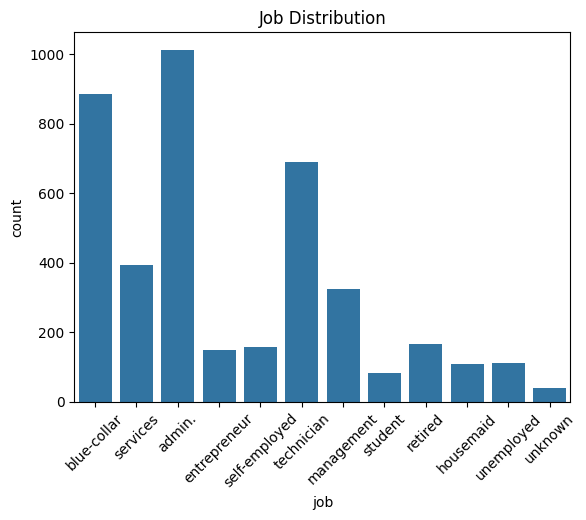

In [14]:
plt.figure()
sns.countplot(data=df, x="job")
plt.xticks(rotation=45)
plt.title("Job Distribution")
plt.show()

order them

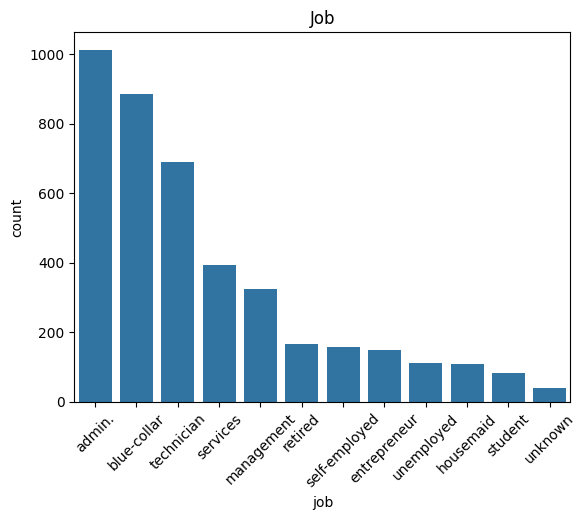

In [15]:
plt.figure()
sns.countplot(data=df, x="job", order=df["job"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Job")
plt.show()

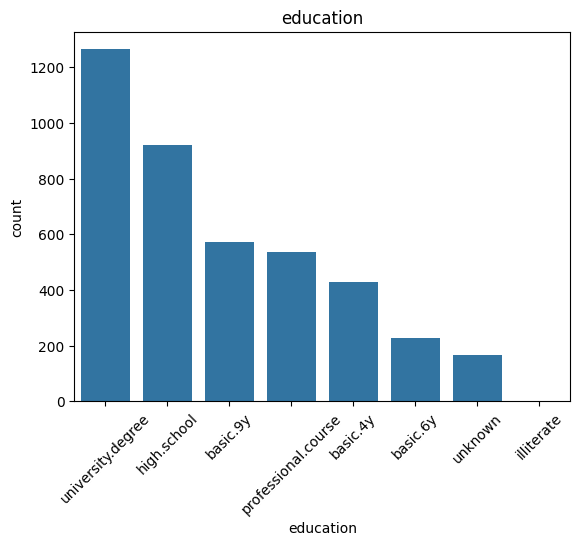

In [16]:
plt.figure()
sns.countplot(data=df, x="education", order=df["education"].value_counts().index)
plt.title("education")
plt.xticks(rotation=45)
plt.show()

Identify at least one variable that may require special consideration before modeling (e.g., due to distributional properties, extreme skewness, or availability at prediction time), and briefly justify your reasoning.

ANS: duration (numerical variable)

Readon1: it represents the length of the phone call, which is only known after the call ends. 
If the prediction is made at the time of contact, using this variable would introduce data leakage.

To review: 
(Data leackage: when information from outside your training data leaks into your machine learning model while it’s being built.)

Reason2: distribution above is extremely right skewed. This might affect model behavior, and it might need a transformation.

## 3. Data Splitting

Split the dataset into training, validation, and test sets.
• Justify your choice of proportions for each split.
• Perform stratified splitting with respect to the target variable and explain why stratification is necessary for
this dataset.
• Clearly describe at which stage of your pipeline the split must occur, and explain what types of data leakage
would arise if splitting were performed later.

WHY data splitting now?

If we perform preprocessing before splitting, information from the validation or test set may leak into the training process.
Data splitting must occur before any preprocessing steps that learn parameters from the data. If splitting were performed after these transformations, information from the validation or test sets would be incorporated into the training process. This would result in data leakage.

For example:
- If imputation is performed before splitting, the overall dataset mean would be used to fill missing values.
- If scaling is done before splitting, the mean and standard deviation would be calculated using the entire dataset.
- If feature selection is applied before splitting, features would be chosen based on patterns from all data, including the test set.
- If resampling is done before splitting, synthetic samples could appear in the validation or test sets.

In all of these cases, information from the test data would influence the training process, leading to data leakage.
Such leakage would lead to overly optimistic results and reduce the reliability of model performance.

Therefore, data splitting is performed  at this stage.

Split the dataset into training, validation, and test sets.
Justify your choice of proportions for each split.
Perform stratified splitting with respect to the target variable and explain why stratification is necessary for
this dataset.


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X = df.drop("y", axis=1)
y = df["y"]

In [23]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=10
)

In [24]:

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=10
)

Justification of the Data Split Proportion

The dataset was split into 70% training, 15% validation, and 15% test sets.

First, 70% of the data to the training set ensures that the model has enough data to learn patterns.

Second, separate validation and test sets are necessary to avoid data leakage. The validation set is used for model tuning and selection, and the test set is for final unbiased evaluation.

Finally, since the dataset is imbalanced (target variable y is 3668/451), allocating 15% to both validation and test sets ensures that each subset contains enough minority class examples for reliable evaluation.

## 4. Missing value handling
Identify both explicit missing values (e.g., NaN) and implicit missing values (e.g., categories such as unknown
or sentinel numerical values, i.e., values that may represent special codes rather than genuine measurements).
- Quantify the extent of missingness for each affected variable.
- Propose and justify a strategy for handling missing values in each case (e.g., removal, imputation, separate
category, indicator variable).
- Clearly state which operations must be fitted using the training set only, and explain why.

Note: Your strategy should distinguish between “data cleaning” decisions (e.g., correcting inconsistent entries)
and “modeling” decisions (e.g., whether missingness itself may carry predictive information).

First, check explicit missing value(NaN)

In [30]:
X_train.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64

Next, check imexlicit missing value(such as unknown)

In [31]:
for col in X_train.columns:
    count_unknown = (X_train[col] == "unknown").sum()
    if count_unknown > 0:
        print(f" variable: ({col}) {count_unknown} unknown values")

 variable: (job) 26 unknown values
 variable: (marital) 9 unknown values
 variable: (education) 120 unknown values
 variable: (default) 575 unknown values
 variable: (housing) 77 unknown values
 variable: (loan) 77 unknown values


#### Missing Value Strategy

There are no explicit missing values (NaN) in the dataset. However, several categorical variables contain the value "unknown", 
which might represent unrecorded information.

We distinguish between data cleaning decisions and modeling decisions.

From a data cleaning perspective, there are no corrupted entries that require correction. So i do not need to remoce any rows.

From a modeling perspective, the inexplicit missing value unknown may carry predictive information, so instead of removing these observations or imputing them, I treat "unknown" as a separate category. 
This avoids information loss and allows the model to learn whether missingness itself is informative.

If numerical missing values were present, we would apply median imputation, fitted on the training set only. 
In Lecture 5, it says that imputation estimates statistical parameters from data, and therefore must not use validation or test data to avoid data leakage.

All preprocessing steps that learn parameters are fitted using the training set only and then applied to validation and test sets.

## 4. Encoding categorical variables: Identify all categorical variables in the dataset.
- Distinguish between nominal variables (categories without intrinsic order, e.g., job type) and ordinal variables
(categories with a meaningful order, e.g., education level), and justify your classification.
- Select and apply an appropriate encoding strategy for each categorical variable.
- Clearly state which encoders must be fitted on the training set only, and explain why.
  
- Analyze how encoding changes:
– the dimensionality of the dataset;
– the interpretability of model coefficients;
– the types of decision boundaries a linear model can represent.

#### Identification of Categorical Variables
Variables below are categorical:
job, marital, education, default, housing, loan, contact, month, day_of_week, and poutcome.

Nominal vs Ordinal Variables
- Most categorical variables in this dataset are nominal, meaning they do not have an intrinsic order (e.g., job type, marital status, contact type).
- The variable `education` could be considered ordinal since education levels follow a natural progression. However, the exact numeric distance between these categories is unclear. 
Therefore, all categorical variables are treated as nominal.

Encoding Strategy: One-Hot Encoding to all categorical variables.
- It's appropriate for nominal variables.
- Does not impose artificial ordering on categories.
- Expands the feature space, allowing the linear model to capture category specific effects.
- Although education has an order, we apply one-hot encoding to avoid imposing a linear distance assumption between education levels.
- This allows the model to learn category-specific effects without assuming equal spacing between levels.

The encoder is fitted using only the training data and then applied to validation and test sets. 
This prevents data leakage, since encoding learns category mappings from the data.

In [34]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
categorical_cols

/var/folders/yr/kg6lw55s2jgdrr2__8l6grc80000gn/T/ipykernel_98236/2654008446.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [35]:
from sklearn.preprocessing import OneHotEncoder

In [36]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

In [38]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

categorical_cols = X_train.select_dtypes(include=["str"]).columns.tolist()
numerical_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

In [39]:
categorical_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [40]:
numerical_cols

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [47]:
# Step 2: Initialize encoder (version-safe)
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

#### Note on AI Use on above block

During implementation, a version-related error occurred due to differences in the OneHotEncoder arguments across scikit-learn versions. 
I use AI assistance to quickly identify the cause of the error and adapt the code accordingly. 

In [48]:
encoder.fit(X_train[categorical_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [49]:
X_train_cat = encoder.transform(X_train[categorical_cols])
X_val_cat   = encoder.transform(X_val[categorical_cols])
X_test_cat  = encoder.transform(X_test[categorical_cols])

combine with numerical variabels 

In [50]:
X_train_final = np.concatenate(
    [X_train[numerical_cols].values, X_train_cat],
    axis=1
)

X_val_final = np.concatenate(
    [X_val[numerical_cols].values, X_val_cat],
    axis=1
)

X_test_final = np.concatenate(
    [X_test[numerical_cols].values, X_test_cat],
    axis=1
)

In [51]:
print(X_train_final.shape)

(2883, 63)


In [52]:
print("Trai set:", X_train_final.shape)
print("Val:", X_val_final.shape)
print("Test set:", X_test_final.shape)

Train: (2883, 63)
Val: (618, 63)
Test: (618, 63)


#### Impact on Dimensionality
One-Hot Encoding increases the number of features in the dataset.  Since each category is converted into its own binary column, the total number of variables grows.  This expands the feature space and makes the dataset higher-dimensional.

#### Impact on Interpretability
In Logistic Regression, each encoded category has its own coefficient.  This makes it easier to understand how a specific category (for example, a certain job type) influences the probability of subscription compared to a reference category. Therefore, One-Hot Encoding helps maintain interpretability of the model.

#### Impact on Decision Boundaries
Logistic Regression is a linear model, meaning it learns a linear decision boundary in the feature space.  By expanding the feature space through One-Hot Encoding, the model becomes more flexible.  Although the boundary is still linear in the transformed space, it can represent different effects for different categories, which would not be possible without encoding.